In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [2]:
iris=load_iris()
X=iris.data      
y=iris.target

In [4]:
X_mean=np.mean(X,axis=0)
X_std=np.std(X,axis=0)
X_norm=(X-X_mean)/X_std

In [5]:
encoder = OneHotEncoder(sparse_output=False)
y_ohe = encoder.fit_transform(y.reshape(-1, 1))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_ohe, test_size=0.2, random_state=42
)

In [7]:
n_input  = 4 
n_hidden = 16 
n_output = 3 

In [9]:

np.random.seed(42)
W1 = np.random.randn(n_input, n_hidden) * 0.01 
b1 = np.zeros((1, n_hidden))                     
W2 = np.random.randn(n_hidden, n_output) * 0.01  
b2 = np.zeros((1, n_output))

In [10]:
def relu(z):
    return np.maximum(0, z)

In [11]:
def relu_derivative(z):
    return (z > 0).astype(float)

In [12]:
def softmax(z):
    # Subtract max per row for numerical stability before exponentiating
    shifted = z - np.max(z, axis=1, keepdims=True)
    exp_z   = np.exp(shifted)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [13]:
def cross_entropy_loss(y_true, y_pred):
    # Clip to avoid log(0) blowing up to -inf
    y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
    n = y_true.shape[0]
    # Average negative log likelihood over all samples
    return -np.sum(y_true * np.log(y_pred)) / n

In [14]:
def forward(X):
    z1 = X @ W1 + b1       # (n_samples, 16)
    a1 = relu(z1)           # (n_samples, 16)
    z2 = a1 @ W2 + b2      # (n_samples, 3)
    a2 = softmax(z2)        # (n_samples, 3) — probabilities summing to 1

    return z1, a1, z2, a2

In [15]:
def backward(X, y_true, z1, a1, z2, a2):
    n = X.shape[0]
    # Output layer: softmax + cross-entropy gradient simplifies to (a2 - y_true)
    dz2 = (a2 - y_true) / n          # (n_samples, 3)
    dW2 = a1.T @ dz2                  # (16, 3)
    db2 = np.sum(dz2, axis=0, keepdims=True)  # (1, 3)

    # Hidden layer: backprop through ReLU
    da1 = dz2 @ W2.T                  # (n_samples, 16)
    dz1 = da1 * relu_derivative(z1)   # (n_samples, 16)
    dW1 = X.T @ dz1                   # (4, 16)
    db1 = np.sum(dz1, axis=0, keepdims=True)  # (1, 16)

    return dW1, db1, dW2, db2

In [16]:
learning_rate = 0.1
epochs        = 1000
loss_history  = []

for epoch in range(epochs):
    # Forward pass
    z1, a1, z2, a2 = forward(X_train)

    # Compute loss
    loss = cross_entropy_loss(y_train, a2)
    loss_history.append(loss)

    # Backward pass
    dW1, db1, dW2, db2 = backward(X_train, y_train, z1, a1, z2, a2)

    # Gradient descent weight update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

Epoch    0 | Loss: 1.0986
Epoch  100 | Loss: 0.5601
Epoch  200 | Loss: 0.2962
Epoch  300 | Loss: 0.1832
Epoch  400 | Loss: 0.1239
Epoch  500 | Loss: 0.0959
Epoch  600 | Loss: 0.0814
Epoch  700 | Loss: 0.0728
Epoch  800 | Loss: 0.0671
Epoch  900 | Loss: 0.0632


In [17]:
def predict(X):
    _, _, _, a2 = forward(X)
    # Class with highest probability is the prediction
    return np.argmax(a2, axis=1)

def accuracy(X, y_ohe):
    preds       = predict(X)
    true_labels = np.argmax(y_ohe, axis=1)
    return np.mean(preds == true_labels)

train_acc = accuracy(X_train, y_train)
test_acc  = accuracy(X_test,  y_test)

print(f"\nTrain accuracy: {train_acc * 100:.1f}%")
print(f"Test  accuracy: {test_acc  * 100:.1f}%")


Train accuracy: 98.3%
Test  accuracy: 100.0%


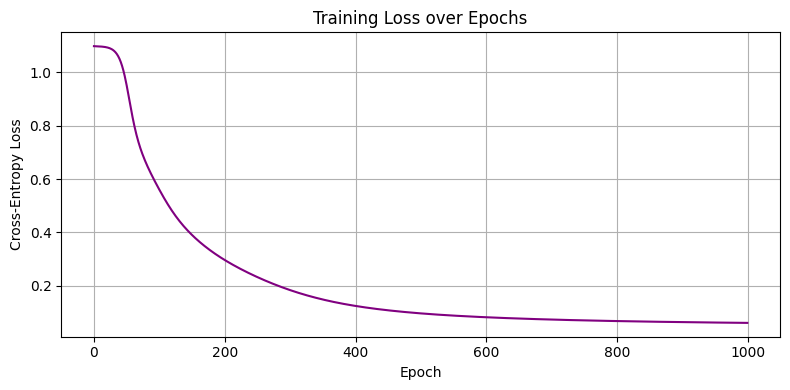

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='purple')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.tight_layout()
plt.show()